In [ ]:
# This is to clean the data
def is_yahoo_style(df):
    return (
        "Price" in df.columns and
        df.iloc[0, 0] == "Ticker" and
        df.iloc[1, 0] == "Date"
    )

def parse_yahoo(df):
    # drop the two junk rows
    df = df.iloc[2:].copy()

    # fix column name
    df.rename(columns={"Price": "Date"}, inplace=True)

    # parse Date properly
    df["Date"] = pd.to_datetime(df["Date"])

    # optional but good hygiene
    df.reset_index(drop=True, inplace=True)

    return df

import zipfile
import pandas as pd
import os

zip_path = r"C:\Users\jolin\OneDrive\Documents\Dathaton\gfc.zip"

output_folder = "cleaned_csv_gfc"     # folder to save cleaned files

# create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# functions you already have
def is_yahoo_style(df):
    return (
        "Price" in df.columns and
        df.iloc[0, 0] == "Ticker" and
        df.iloc[1, 0] == "Date"
    )

def parse_yahoo(df):
    df = df.iloc[2:].copy()                # drop first 2 junk rows
    df.rename(columns={"Price": "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"])
    df.reset_index(drop=True, inplace=True)
    return df

# process each CSV in the ZIP
with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if not filename.endswith(".csv"):
            continue

        with z.open(filename) as f:
            df = pd.read_csv(f)

        if is_yahoo_style(df):
            print(f"\nParsing Yahoo-style file: {filename}")
            df = parse_yahoo(df)
        else:
            print(f"\nLeaving file unchanged: {filename}")

        # save cleaned CSV
        # use just the basename to avoid nested folders
        output_path = os.path.join(output_folder, os.path.basename(filename))
        df.to_csv(output_path, index=False)

        print(f"Saved cleaned file to: {output_path}")


Parsing Yahoo-style file: gfc data/AIG.csv
Saved cleaned file to: cleaned_csv_gfc\AIG.csv

Parsing Yahoo-style file: gfc data/^VIX.csv
Saved cleaned file to: cleaned_csv_gfc\^VIX.csv

Parsing Yahoo-style file: gfc data/C.csv
Saved cleaned file to: cleaned_csv_gfc\C.csv

Parsing Yahoo-style file: gfc data/JPM.csv
Saved cleaned file to: cleaned_csv_gfc\JPM.csv

Parsing Yahoo-style file: gfc data/^GSPC.csv
Saved cleaned file to: cleaned_csv_gfc\^GSPC.csv

Leaving file unchanged: gfc data/WGS3MO.csv
Saved cleaned file to: cleaned_csv_gfc\WGS3MO.csv

Parsing Yahoo-style file: gfc data/^DJI.csv
Saved cleaned file to: cleaned_csv_gfc\^DJI.csv

Leaving file unchanged: gfc data/TEDRATE.csv
Saved cleaned file to: cleaned_csv_gfc\TEDRATE.csv


In [22]:
#This is to view the data (first 5 rows)
import zipfile
import pandas as pd

zip_path = r"C:\Users\jolin\OneDrive\Documents\Dathaton\gfc.zip"

def is_yahoo_style(df: pd.DataFrame) -> bool:
    # Yahoo-style: first column header is "Price", and first row starts with "Ticker"
    return (
        "Price" in df.columns
        and len(df) >= 2
        and str(df.iloc[0, 0]).strip() == "Ticker"
        and str(df.iloc[1, 0]).strip() == "Date"
    )

def clean_yahoo_df(df: pd.DataFrame) -> pd.DataFrame:
    # 1) drop the two junk rows
    df = df.iloc[2:].copy()

    # 2) rename "Price" -> "Date"
    df.rename(columns={"Price": "Date"}, inplace=True)

    # 3) parse Date
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # 4) convert numeric columns safely
    for col in ["Close", "High", "Low", "Open", "Volume"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 5) format Date like 3/1/2005 (Windows needs %#d %#m)
    df["Date"] = df["Date"].dt.strftime("%#d/%#m/%Y")

    # 6) rounding + volume int
    price_cols = [c for c in ["Close", "High", "Low", "Open"] if c in df.columns]
    df[price_cols] = df[price_cols].round(5)

    if "Volume" in df.columns:
        df["Volume"] = df["Volume"].fillna(0).astype(int)

    # 7) reorder columns (only keep the ones that exist)
    desired = ["Date", "Close", "High", "Low", "Open", "Volume"]
    df = df[[c for c in desired if c in df.columns]]

    # 8) reset index
    df.reset_index(drop=True, inplace=True)

    return df

with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if not filename.endswith(".csv"):
            continue

        with z.open(filename) as f:
            df = pd.read_csv(f)

        print("\n" + "=" * 70)
        print(f"📄 File: {filename}")
        print("=" * 70)

        if is_yahoo_style(df):
            df_clean = clean_yahoo_df(df)
            print("✅ Yahoo-style detected → cleaned format preview:")
            print(df_clean.head())
        else:
            print("ℹ️ Not Yahoo-style → raw preview:")
            print(df.head())




📄 File: gfc data/AIG.csv
✅ Yahoo-style detected → cleaned format preview:
       Date      Close       High        Low       Open  Volume
0  3/1/2005  789.59564  799.52088  788.87818  790.43273  379590
1  4/1/2005  792.22687  799.99966  790.55270  793.42268  379110
2  5/1/2005  805.38043  812.67487  796.65101  797.60764  558800
3  6/1/2005  806.69598  812.43595  799.99946  801.19527  408765
4  7/1/2005  808.13092  811.71836  804.30430  807.77219  311070

📄 File: gfc data/^VIX.csv
✅ Yahoo-style detected → cleaned format preview:
       Date  Close   High    Low   Open  Volume
0  3/1/2005  14.08  14.23  13.25  13.39       0
1  4/1/2005  13.98  14.45  13.93  14.01       0
2  5/1/2005  14.09  14.09  13.26  13.98       0
3  6/1/2005  13.58  14.09  13.33  14.09       0
4  7/1/2005  13.49  13.51  12.94  13.47       0

📄 File: gfc data/C.csv
✅ Yahoo-style detected → cleaned format preview:
       Date      Close       High        Low       Open   Volume
0  3/1/2005  299.30054  303.82693  298.

In [23]:
#This is to summarise data
import pandas as pd
import numpy as np
from datetime import datetime

def analyze_stock_data(df, filename=""):
    """
    Comprehensive stock data analysis with statistics and anomalies.
    """
    print("\n" + "=" * 80)
    print(f"📊 ANALYSIS: {filename}")
    print("=" * 80)
    
    # Convert Date back to datetime for analysis
    df_analysis = df.copy()
    df_analysis["Date"] = pd.to_datetime(df_analysis["Date"], format="%d/%m/%Y")
    df_analysis = df_analysis.sort_values("Date").reset_index(drop=True)
    
    # === BASIC STATISTICS ===
    print("\n📈 BASIC STATISTICS")
    print("-" * 80)
    
    for col in ["Close", "High", "Low", "Open", "Volume"]:
        if col not in df_analysis.columns:
            continue
            
        data = pd.to_numeric(df_analysis[col], errors="coerce").dropna()
        
        print(f"\n{col}:")
        print(f"  Min:    {data.min():.2f}")
        print(f"  Max:    {data.max():.2f}")
        print(f"  Mean:   {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std:    {data.std():.2f}")
        print(f"  Range:  {data.max() - data.min():.2f}")
    
    # === DATE RANGE ===
    print(f"\n📅 DATE RANGE")
    print("-" * 80)
    start_date = df_analysis["Date"].min()
    end_date = df_analysis["Date"].max()
    duration = (end_date - start_date).days
    print(f"  Start: {start_date.strftime('%d/%m/%Y')}")
    print(f"  End:   {end_date.strftime('%d/%m/%Y')}")
    print(f"  Duration: {duration} days ({duration / 365.25:.1f} years)")
    
    # === UNUSUAL SPIKES/DROPS (Outliers using IQR) ===
    print(f"\n🔴 UNUSUAL SPIKES OR DROPS (Outliers > 1.5×IQR)")
    print("-" * 80)
    
    if "Close" in df_analysis.columns:
        close = pd.to_numeric(df_analysis["Close"], errors="coerce")
        Q1 = close.quantile(0.25)
        Q3 = close.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_analysis[(close < lower_bound) | (close > upper_bound)].copy()
        outliers["Close_Val"] = close[(close < lower_bound) | (close > upper_bound)]
        outliers = outliers.sort_values("Close_Val", ascending=False)
        
        if len(outliers) > 0:
            print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            for idx, row in outliers.head(10).iterrows():
                date = row["Date"].strftime('%d/%m/%Y')
                price = row["Close_Val"]
                print(f"  {date}: {price:.2f}")
        else:
            print("  ✅ No unusual outliers detected")
    
    print("\n" + "=" * 80)

# Add this after your existing cleaning code
output_folder = "cleaned_csv_gfc"

with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if not filename.endswith(".csv"):
            continue

        with z.open(filename) as f:
            df = pd.read_csv(f)

        if is_yahoo_style(df):
            df_clean = clean_yahoo_df(df)
            
            # Save the file
            output_path = os.path.join(output_folder, os.path.basename(filename))
            df_clean.to_csv(output_path, index=False)
            
            # Run analysis
            analyze_stock_data(df_clean, filename)


📊 ANALYSIS: gfc data/AIG.csv

📈 BASIC STATISTICS
--------------------------------------------------------------------------------

Close:
  Min:    4.40
  Max:    889.28
  Mean:   346.65
  Median: 30.30
  Std:    363.69
  Range:  884.88

High:
  Min:    4.65
  Max:    893.08
  Mean:   350.56
  Median: 31.25
  Std:    366.52
  Range:  888.43

Low:
  Min:    4.15
  Max:    887.32
  Mean:   342.96
  Median: 28.63
  Std:    360.78
  Range:  883.17

Open:
  Min:    4.65
  Max:    889.89
  Mean:   347.05
  Median: 30.21
  Std:    363.78
  Range:  885.24

Volume:
  Min:    109395.00
  Max:    322510400.00
  Mean:   7389365.18
  Median: 2513305.00
  Std:    16795758.38
  Range:  322401005.00

📅 DATE RANGE
--------------------------------------------------------------------------------
  Start: 03/01/2005
  End:   28/12/2012
  Duration: 2916 days (8.0 years)

🔴 UNUSUAL SPIKES OR DROPS (Outliers > 1.5×IQR)
--------------------------------------------------------------------------------
  ✅ No u

In [24]:
#This is to convert all price series into comparable units
import pandas as pd
import os

# folder with your cleaned CSVs
folder = "cleaned_csv_gfc"

files = {
    "AIG": "AIG.csv",
    "Citigroup": "C.csv",
    "JPMorgan": "JPM.csv",
    "S&P500": "^GSPC.csv"
}

# load Close prices
dfs = []

for name, file in files.items():
    path = os.path.join(folder, file)
    
    if not os.path.exists(path):
        print(f"⚠️  File not found: {path}")
        continue
    
    try:
        df = pd.read_csv(path)
        df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
        df = df[["Date", "Close"]].rename(columns={"Close": name})
        df = df.dropna()  # Remove rows with invalid dates
        dfs.append(df)
        print(f"✅ Loaded: {name}")
    except Exception as e:
        print(f"❌ Error loading {name}: {e}")

if len(dfs) < 2:
    print("❌ Not enough files loaded to merge!")
else:
    # merge on Date (align timelines)
    merged = dfs[0]
    for df in dfs[1:]:
        merged = merged.merge(df, on="Date", how="inner")

    merged = merged.sort_values("Date").reset_index(drop=True)

    # normalise prices (start = 100)
    norm = merged.copy()

    for col in norm.columns:
        if col != "Date":
            norm[col] = (norm[col] / norm[col].iloc[0]) * 100

    print(f"\n✅ Merged {len(norm)} rows")
    print(norm.head())

✅ Loaded: AIG
✅ Loaded: Citigroup
✅ Loaded: JPMorgan
✅ Loaded: S&P500

✅ Merged 2012 rows
        Date         AIG   Citigroup    JPMorgan      S&P500
0 2005-01-03  100.000000  100.000000  100.000000  100.000000
1 2005-01-04  100.333238   99.150626   98.969330   98.832864
2 2005-01-05  101.999098  100.393628   99.175464   98.474314
3 2005-01-06  102.165709  101.367261   99.742321   98.819550
4 2005-01-07  102.347440  100.787245   98.943536   98.678123


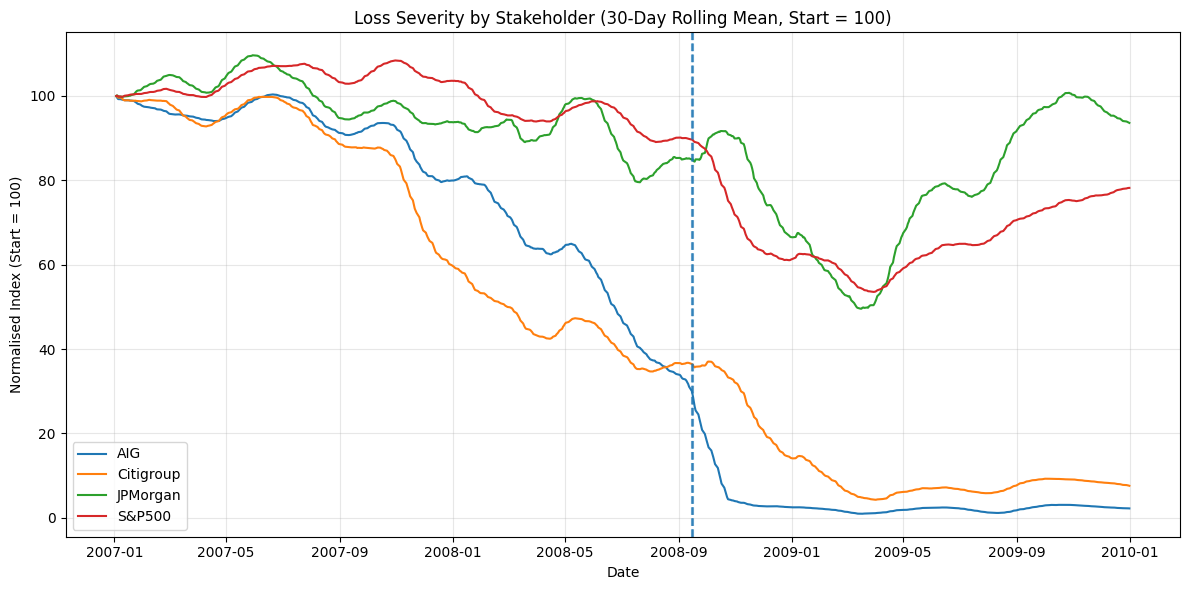

Window start/end: 2007-01-03 00:00:00 2009-12-31 00:00:00
Baseline date: 2007-01-03 00:00:00
Baseline values (should be 100):
AIG          100.0
Citigroup    100.0
JPMorgan     100.0
S&P500       100.0
Name: 0, dtype: float64


In [28]:
#Visualisation 1 (Main figure): Loss severity by stakeholder
import pandas as pd
import matplotlib.pyplot as plt

# 1) Set window
start_date = "2007-01-01"
end_date   = "2009-12-31"

# 2) Filter FIRST (use your aligned raw price table)
window = merged[(merged["Date"] >= start_date) & (merged["Date"] <= end_date)].copy()
window = window.sort_values("Date").reset_index(drop=True)

# 3) Normalise AFTER filtering (Start=100 at 2007-01-01)
norm_window = window.copy()
for col in norm_window.columns:
    if col != "Date":
        norm_window[col] = (norm_window[col] / norm_window[col].iloc[0]) * 100

# 4) Rolling mean (30 trading days)
smooth = norm_window.set_index("Date").rolling(window=30, min_periods=1).mean()

# 5) Plot
plt.figure(figsize=(12,6))
for col in smooth.columns:
    plt.plot(smooth.index, smooth[col], label=col)

plt.axvline(pd.to_datetime("2008-09-15"), linestyle="--", alpha=0.7)
plt.axvline(pd.to_datetime("2008-09-16"), linestyle="--", alpha=0.7)

plt.title("Loss Severity by Stakeholder (30-Day Rolling Mean, Start = 100)")
plt.xlabel("Date")
plt.ylabel("Normalised Index (Start = 100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# sanity checks
print("Window start/end:", norm_window["Date"].min(), norm_window["Date"].max())
print("Baseline date:", norm_window["Date"].iloc[0])
print("Baseline values (should be 100):")
print(norm_window.drop(columns=["Date"]).iloc[0])







      Series  Max Drawdown (%) Date of Max Drawdown
0        AIG            -99.51           2009-03-05
1  Citigroup            -98.00           2009-03-05
2   JPMorgan            -68.15           2009-03-09
3     S&P500            -56.78           2009-03-09


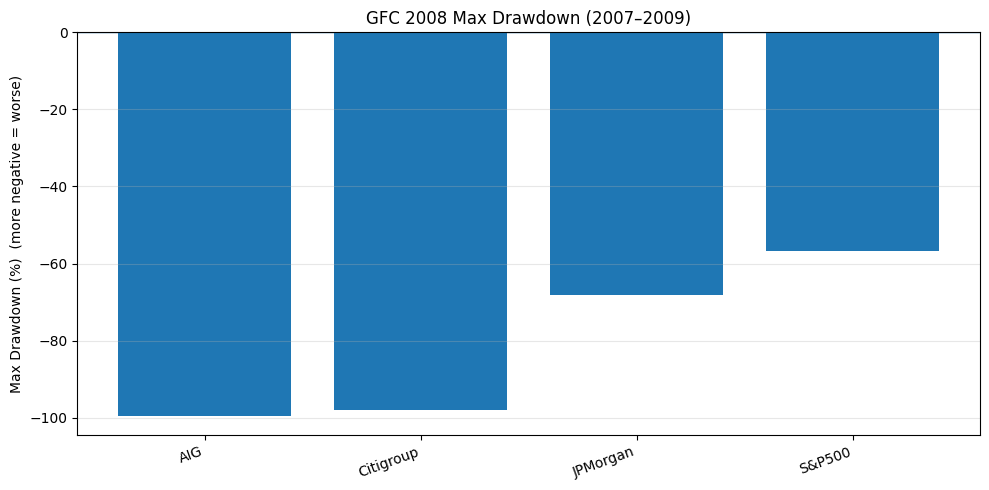

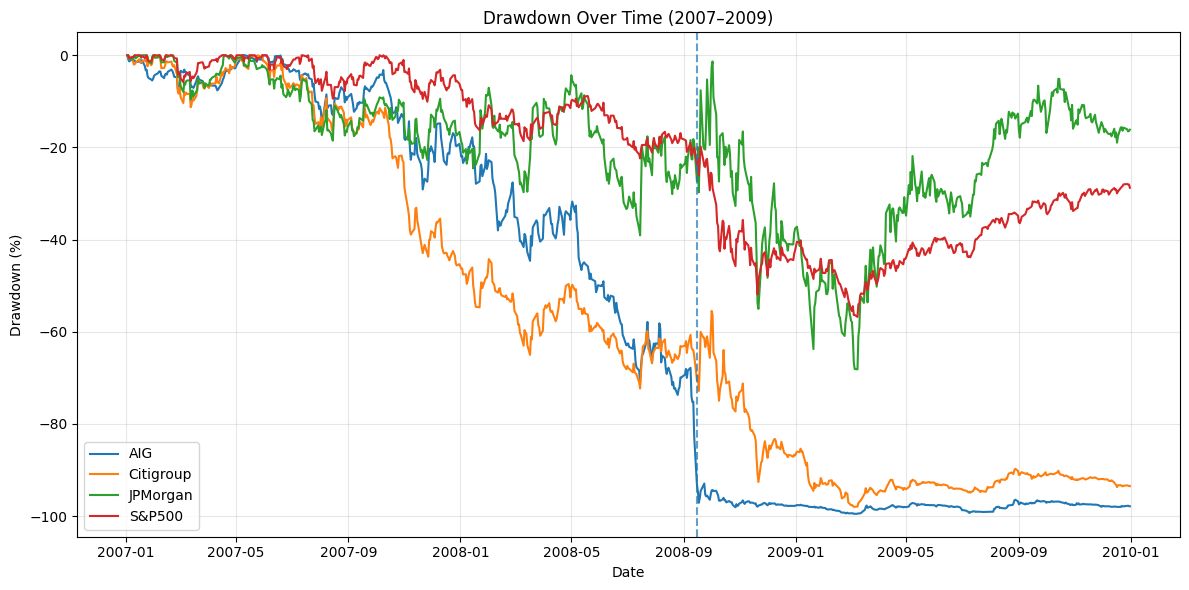

In [36]:
#Visualisation 2: Drawdown “who got hit hardest?”
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Choose your event window
# -----------------------------
start_date = "2007-01-01"
end_date   = "2009-12-31"

# merged should be your aligned raw prices table:
# columns: Date + ["AIG", "Citigroup (C)", "JPMorgan (JPM)", "S&P 500 (^GSPC)"] (or similar)
# If your column names differ, edit series_cols below to match.

# -----------------------------
# 1) Pick the series columns to use
# -----------------------------
# ✅ Edit these names to match your merged dataframe columns exactly
series_cols = [
    "AIG",
    "Citigroup",
    "JPMorgan",
    "S&P500"
]

# -----------------------------
# 2) Filter the window
# -----------------------------
window = merged[(merged["Date"] >= start_date) & (merged["Date"] <= end_date)].copy()
window = window.sort_values("Date").reset_index(drop=True)

# Keep only Date + chosen series
window = window[["Date"] + series_cols].dropna()

# -----------------------------
# 3) Compute drawdowns (peak-to-date)
# -----------------------------
drawdowns = pd.DataFrame({"Date": window["Date"]})

for col in series_cols:
    running_peak = window[col].cummax()
    drawdowns[col] = (window[col] / running_peak) - 1  # negative values

# -----------------------------
# 4) Compute max drawdown + date of max drawdown
# -----------------------------
summary = []
for col in series_cols:
    mdd = drawdowns[col].min()  # most negative point
    mdd_date = drawdowns.loc[drawdowns[col].idxmin(), "Date"]
    summary.append({
        "Series": col,
        "Max Drawdown (%)": round(mdd * 100, 2),
        "Date of Max Drawdown": mdd_date.strftime("%Y-%m-%d")
    })

summary_df = pd.DataFrame(summary).sort_values("Max Drawdown (%)")  # more negative = worse

print(summary_df)

# -----------------------------
# 5) Bar chart: who got hit hardest? (super clean)
# -----------------------------
plt.figure(figsize=(10,5))
plt.bar(summary_df["Series"], summary_df["Max Drawdown (%)"])
plt.axhline(0, linewidth=1)
plt.title("GFC 2008 Max Drawdown (2007–2009)")
plt.ylabel("Max Drawdown (%)  (more negative = worse)")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# (Optional) 6) Drawdown over time (line chart)
# -----------------------------
plt.figure(figsize=(12,6))
for col in series_cols:
    plt.plot(drawdowns["Date"], drawdowns[col] * 100, label=col)

plt.axvline(pd.to_datetime("2008-09-15"), linestyle="--", alpha=0.7)
plt.title("Drawdown Over Time (2007–2009)")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


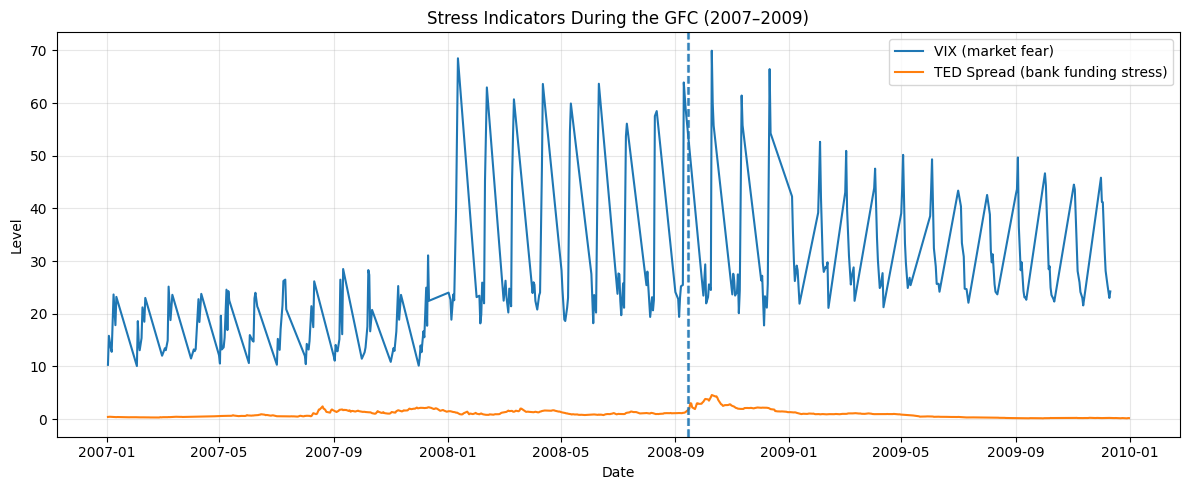

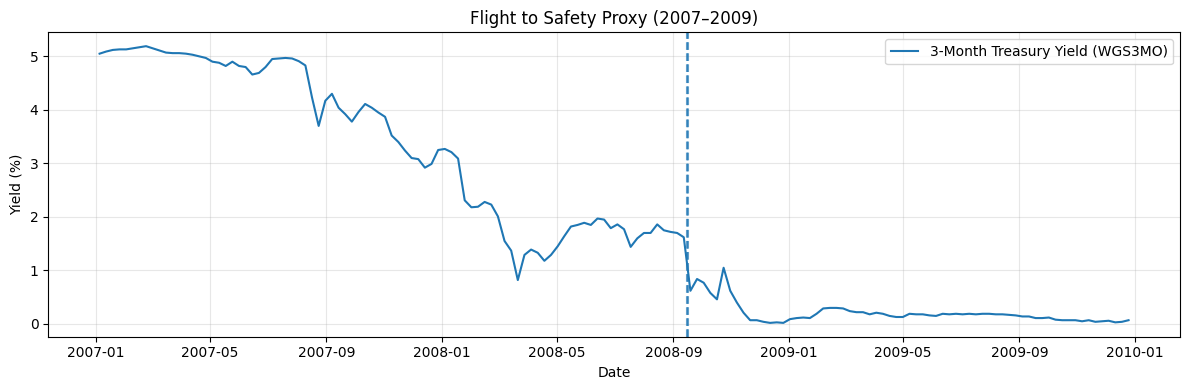

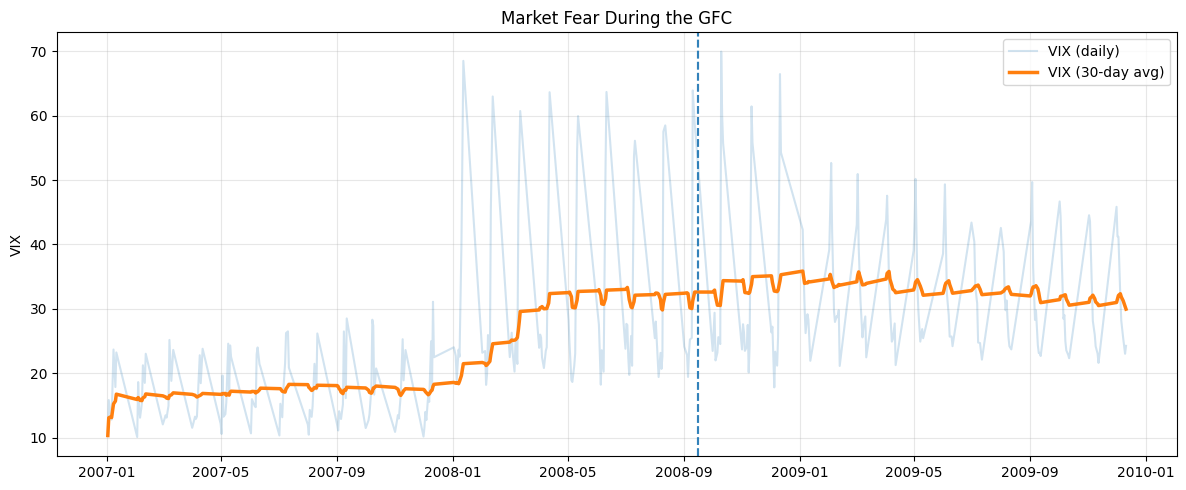

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

folder = "cleaned_csv_gfc"

# --- File paths (adjust if your filenames differ) ---
vix_path = os.path.join(folder, "^VIX.csv")
ted_path = os.path.join(folder, "TEDRATE.csv")
wgs_path = os.path.join(folder, "WGS3MO.csv")  # optional

# --- Event window (match your other slides) ---
start_date = "2007-01-01"
end_date   = "2009-12-31"

# --- Key dates ---
lehman = pd.to_datetime("2008-09-15")
mmf    = pd.to_datetime("2008-09-16")

# -----------------------------
# 1) Load VIX (Yahoo-style: Date + Close)
# -----------------------------
vix = pd.read_csv(vix_path)
vix["Date"] = pd.to_datetime(vix["Date"], errors="coerce", dayfirst=False)
vix["VIX"] = pd.to_numeric(vix["Close"], errors="coerce")
vix = vix[["Date", "VIX"]].dropna().sort_values("Date")
vix = vix.groupby("Date", as_index=False).last()

# -----------------------------
# 2) Load TED spread (FRED-style: observation_date + TEDRATE)
# -----------------------------
ted = pd.read_csv(ted_path)

# handle both possible date column names safely
date_col = "observation_date" if "observation_date" in ted.columns else "Date"
val_col  = "TEDRATE" if "TEDRATE" in ted.columns else "Close"

ted[date_col] = pd.to_datetime(ted[date_col], errors="coerce")
ted["TED"] = pd.to_numeric(ted[val_col], errors="coerce")
ted = ted[[date_col, "TED"]].dropna().sort_values(date_col)
ted = ted.rename(columns={date_col: "Date"})
ted = ted.groupby("Date", as_index=False).last()

# -----------------------------
# 3) Optional: Load WGS3MO (3-month Treasury yield)
# -----------------------------
wgs = None
if os.path.exists(wgs_path):
    wgs = pd.read_csv(wgs_path)
    date_col = "observation_date" if "observation_date" in wgs.columns else "Date"
    val_col  = "WGS3MO" if "WGS3MO" in wgs.columns else "Close"

    wgs[date_col] = pd.to_datetime(wgs[date_col], errors="coerce")
    wgs["WGS3MO"] = pd.to_numeric(wgs[val_col], errors="coerce")
    wgs = wgs[[date_col, "WGS3MO"]].dropna().sort_values(date_col)
    wgs = wgs.rename(columns={date_col: "Date"})
    wgs = wgs.groupby("Date", as_index=False).last()
else:
    print("ℹ️ WGS3MO.csv not found — skipping the flight-to-safety chart.")

# -----------------------------
# 4) Filter to your window
# -----------------------------
start_dt = pd.to_datetime(start_date)
end_dt   = pd.to_datetime(end_date)

vix = vix[(vix["Date"] >= start_dt) & (vix["Date"] <= end_dt)]
ted = ted[(ted["Date"] >= start_dt) & (ted["Date"] <= end_dt)]
if wgs is not None:
    wgs = wgs[(wgs["Date"] >= start_dt) & (wgs["Date"] <= end_dt)]

# -----------------------------
# 5) Plot A+B: VIX and TED (separate chart, clearer than dual-axis)
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(vix["Date"], vix["VIX"], label="VIX (market fear)")
ax.plot(ted["Date"], ted["TED"], label="TED Spread (bank funding stress)")

ax.axvline(lehman, linestyle="--", alpha=0.7)
ax.axvline(mmf, linestyle="--", alpha=0.7)

ax.set_title("Stress Indicators During the GFC (2007–2009)")
ax.set_xlabel("Date")
ax.set_ylabel("Level")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Plot C: WGS3MO (flight to safety)
# -----------------------------
if wgs is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(wgs["Date"], wgs["WGS3MO"], label="3-Month Treasury Yield (WGS3MO)")

    plt.axvline(lehman, linestyle="--", alpha=0.7)
    plt.axvline(mmf, linestyle="--", alpha=0.7)

    plt.title("Flight to Safety Proxy (2007–2009)")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



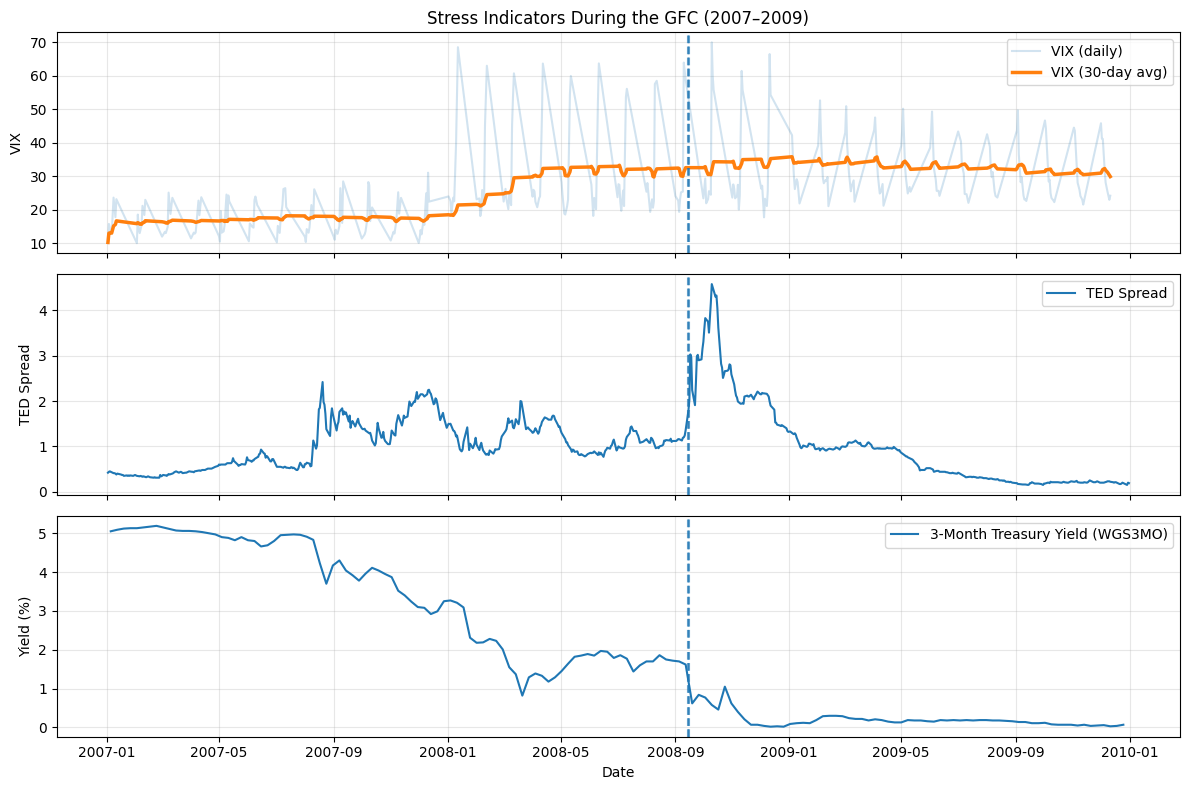

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Add smoothed VIX ---
vix = vix.copy()
vix["VIX_30D"] = vix["VIX"].rolling(30, min_periods=1).mean()

lehman = pd.to_datetime("2008-09-15")
mmf    = pd.to_datetime("2008-09-16")

# Decide if we include WGS3MO panel
include_wgs = (wgs is not None)

nrows = 3 if include_wgs else 2
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(12, 8), sharex=True)

# -----------------------------
# Panel 1: VIX (daily + 30D avg)
# -----------------------------
ax1 = axes[0]
ax1.plot(vix["Date"], vix["VIX"], alpha=0.2, label="VIX (daily)")
ax1.plot(vix["Date"], vix["VIX_30D"], linewidth=2.5, label="VIX (30-day avg)")
ax1.axvline(lehman, linestyle="--", alpha=0.7)
ax1.axvline(mmf, linestyle="--", alpha=0.7)
ax1.set_title("Stress Indicators During the GFC (2007–2009)")
ax1.set_ylabel("VIX")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# -----------------------------
# Panel 2: TED spread
# -----------------------------
ax2 = axes[1]
ax2.plot(ted["Date"], ted["TED"], label="TED Spread")
ax2.axvline(lehman, linestyle="--", alpha=0.7)
ax2.axvline(mmf, linestyle="--", alpha=0.7)
ax2.set_ylabel("TED Spread")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# -----------------------------
# Panel 3 (optional): WGS3MO
# -----------------------------
if include_wgs:
    ax3 = axes[2]
    ax3.plot(wgs["Date"], wgs["WGS3MO"], label="3-Month Treasury Yield (WGS3MO)")
    ax3.axvline(lehman, linestyle="--", alpha=0.7)
    ax3.axvline(mmf, linestyle="--", alpha=0.7)
    ax3.set_ylabel("Yield (%)")
    ax3.set_xlabel("Date")
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc="upper right")
else:
    axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()
